In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix)

In [5]:


from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:

print("MISSING VALUES CHECK")


features_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nChecking how many zeros in each feature (these are missing values):")
for feature in features_with_zero_as_missing:
    zero_count = (df[feature] == 0).sum()
    print(f"  {feature}: {zero_count} zeros ({(zero_count/len(df))*100:.1f}% of data)")


print("HANDLING MISSING VALUES")

df_clean = df.copy()


print("\nReplacing 0 values with MEDIAN for each feature:")

for feature in features_with_zero_as_missing:

    median_value = df_clean[df_clean[feature] != 0][feature].median()
    old_zero_count = (df_clean[feature] == 0).sum()

    df_clean[feature] = df_clean[feature].replace(0, median_value)

    print(f"  {feature}: {old_zero_count} zeros replaced with median = {median_value:.2f}")

print("\nVerification - zeros after cleaning:")
for feature in features_with_zero_as_missing:
    zero_count = (df_clean[feature] == 0).sum()
    print(f"  {feature}: {zero_count} zeros")

MISSING VALUES CHECK

Checking how many zeros in each feature (these are missing values):
  Glucose: 5 zeros (0.7% of data)
  BloodPressure: 35 zeros (4.6% of data)
  SkinThickness: 227 zeros (29.6% of data)
  Insulin: 374 zeros (48.7% of data)
  BMI: 11 zeros (1.4% of data)
HANDLING MISSING VALUES

Replacing 0 values with MEDIAN for each feature:
  Glucose: 5 zeros replaced with median = 117.00
  BloodPressure: 35 zeros replaced with median = 72.00
  SkinThickness: 227 zeros replaced with median = 29.00
  Insulin: 374 zeros replaced with median = 125.00
  BMI: 11 zeros replaced with median = 32.30

Verification - zeros after cleaning:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


In [7]:

X = df_clean.drop('Outcome', axis=1).values
y = df_clean['Outcome'].values


print("DATA PREPARATION\n")

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class Distribution - Non-Diabetic (0): {sum(y==0)}")
print(f"Class Distribution - Diabetic (1): {sum(y==1)}")

DATA PREPARATION

Features shape: (768, 8)
Target shape: (768,)
Class Distribution - Non-Diabetic (0): 500
Class Distribution - Diabetic (1): 268


In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 614 samples
Testing set size: 154 samples


In [9]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done! All features now have mean=0 and std=1")


Scaling done! All features now have mean=0 and std=1


In [10]:

print("PCA (Principal Component Analysis)")

pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA features: {X_train_pca.shape[1]}")
print(f"Variance preserved: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA (Principal Component Analysis)
Original features: 8
PCA features: 6
Variance preserved: 89.85%


In [11]:

print("LDA (Linear Discriminant Analysis)")

lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"LDA features: {X_train_lda.shape[1]}")

LDA (Linear Discriminant Analysis)
Original features: 8
LDA features: 1


In [12]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [13]:

def evaluate_model(X_train_data, X_test_data, y_train, y_test, feature_name):
    print(f"RESULTS: {feature_name}")

    results = {}

    for name, model in models.items():

        model.fit(X_train_data, y_train)


        y_pred = model.predict(X_test_data)


        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)


        results[name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        }


        print(f"\n🔹 {name}")
        print(f"   Accuracy:  {acc*100:.2f}%")
        print(f"   Precision: {prec*100:.2f}%")
        print(f"   Recall:    {rec*100:.2f}%")
        print(f"   F1-Score:  {f1*100:.2f}%")


        cm = confusion_matrix(y_test, y_pred)
        print(f"   Confusion Matrix:")
        print(f"     TN={cm[0][0]}, FP={cm[0][1]}")
        print(f"     FN={cm[1][0]}, TP={cm[1][1]}")

    return results


In [14]:
print(" ORIGINAL FEATURES (8)")

metrics_original = evaluate_model(X_train_scaled, X_test_scaled,
                                       y_train, y_test, "Original Features (8)")

print(" PCA FEATURES (6)")
metrics_pca = evaluate_model(X_train_pca, X_test_pca,
                                  y_train, y_test, "PCA Features (6)")

print(" LDA FEATURES (1)")
metrics_lda = evaluate_model(X_train_lda, X_test_lda,
                                  y_train, y_test, "LDA Features (1)")

 ORIGINAL FEATURES (8)
RESULTS: Original Features (8)

🔹 Logistic Regression
   Accuracy:  75.32%
   Precision: 66.67%
   Recall:    61.82%
   F1-Score:  64.15%
   Confusion Matrix:
     TN=82, FP=17
     FN=21, TP=34

🔹 Random Forest
   Accuracy:  73.38%
   Precision: 62.50%
   Recall:    63.64%
   F1-Score:  63.06%
   Confusion Matrix:
     TN=78, FP=21
     FN=20, TP=35

🔹 SVM
   Accuracy:  74.68%
   Precision: 66.67%
   Recall:    58.18%
   F1-Score:  62.14%
   Confusion Matrix:
     TN=83, FP=16
     FN=23, TP=32

🔹 KNN
   Accuracy:  72.08%
   Precision: 59.68%
   Recall:    67.27%
   F1-Score:  63.25%
   Confusion Matrix:
     TN=74, FP=25
     FN=18, TP=37

🔹 XGBoost
   Accuracy:  71.43%
   Precision: 58.73%
   Recall:    67.27%
   F1-Score:  62.71%
   Confusion Matrix:
     TN=73, FP=26
     FN=18, TP=37
 PCA FEATURES (6)
RESULTS: PCA Features (6)

🔹 Logistic Regression
   Accuracy:  76.62%
   Precision: 69.39%
   Recall:    61.82%
   F1-Score:  65.38%
   Confusion Matrix:
    

In [15]:

print(" COMPLETE COMPARISON TABLE - ALL METRICS\n")

for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f" {metric_name} Comparison:")

    comparison = pd.DataFrame({
        'Model': list(models.keys()),
        'Original (8)': [metrics_original[m][metric_name]*100 for m in models.keys()],
        'PCA (6)': [metrics_pca[m][metric_name]*100 for m in models.keys()],
        'LDA (1)': [metrics_lda[m][metric_name]*100 for m in models.keys()]
    })

    print(comparison.round(2).to_string(index=False))
    print(f"\n Best {metric_name}:")
    for col in ['Original (8)', 'PCA (6)', 'LDA (1)']:
        best_idx = comparison[col].idxmax()
        print(f"  {col}: {comparison.iloc[best_idx]['Model']} ({comparison.iloc[best_idx][col]:.2f}%)")

 COMPLETE COMPARISON TABLE - ALL METRICS

 Accuracy Comparison:
              Model  Original (8)  PCA (6)  LDA (1)
Logistic Regression         75.32    76.62    76.62
      Random Forest         73.38    72.73    70.13
                SVM         74.68    74.68    77.27
                KNN         72.08    72.08    72.08
            XGBoost         71.43    72.73    72.08

 Best Accuracy:
  Original (8): Logistic Regression (75.32%)
  PCA (6): Logistic Regression (76.62%)
  LDA (1): SVM (77.27%)
 Precision Comparison:
              Model  Original (8)  PCA (6)  LDA (1)
Logistic Regression         66.67    69.39    69.39
      Random Forest         62.50    60.66    57.89
                SVM         66.67    66.00    70.83
                KNN         59.68    59.68    60.34
            XGBoost         58.73    60.00    60.34

 Best Precision:
  Original (8): Logistic Regression (66.67%)
  PCA (6): Logistic Regression (69.39%)
  LDA (1): SVM (70.83%)
 Recall Comparison:
              Mo

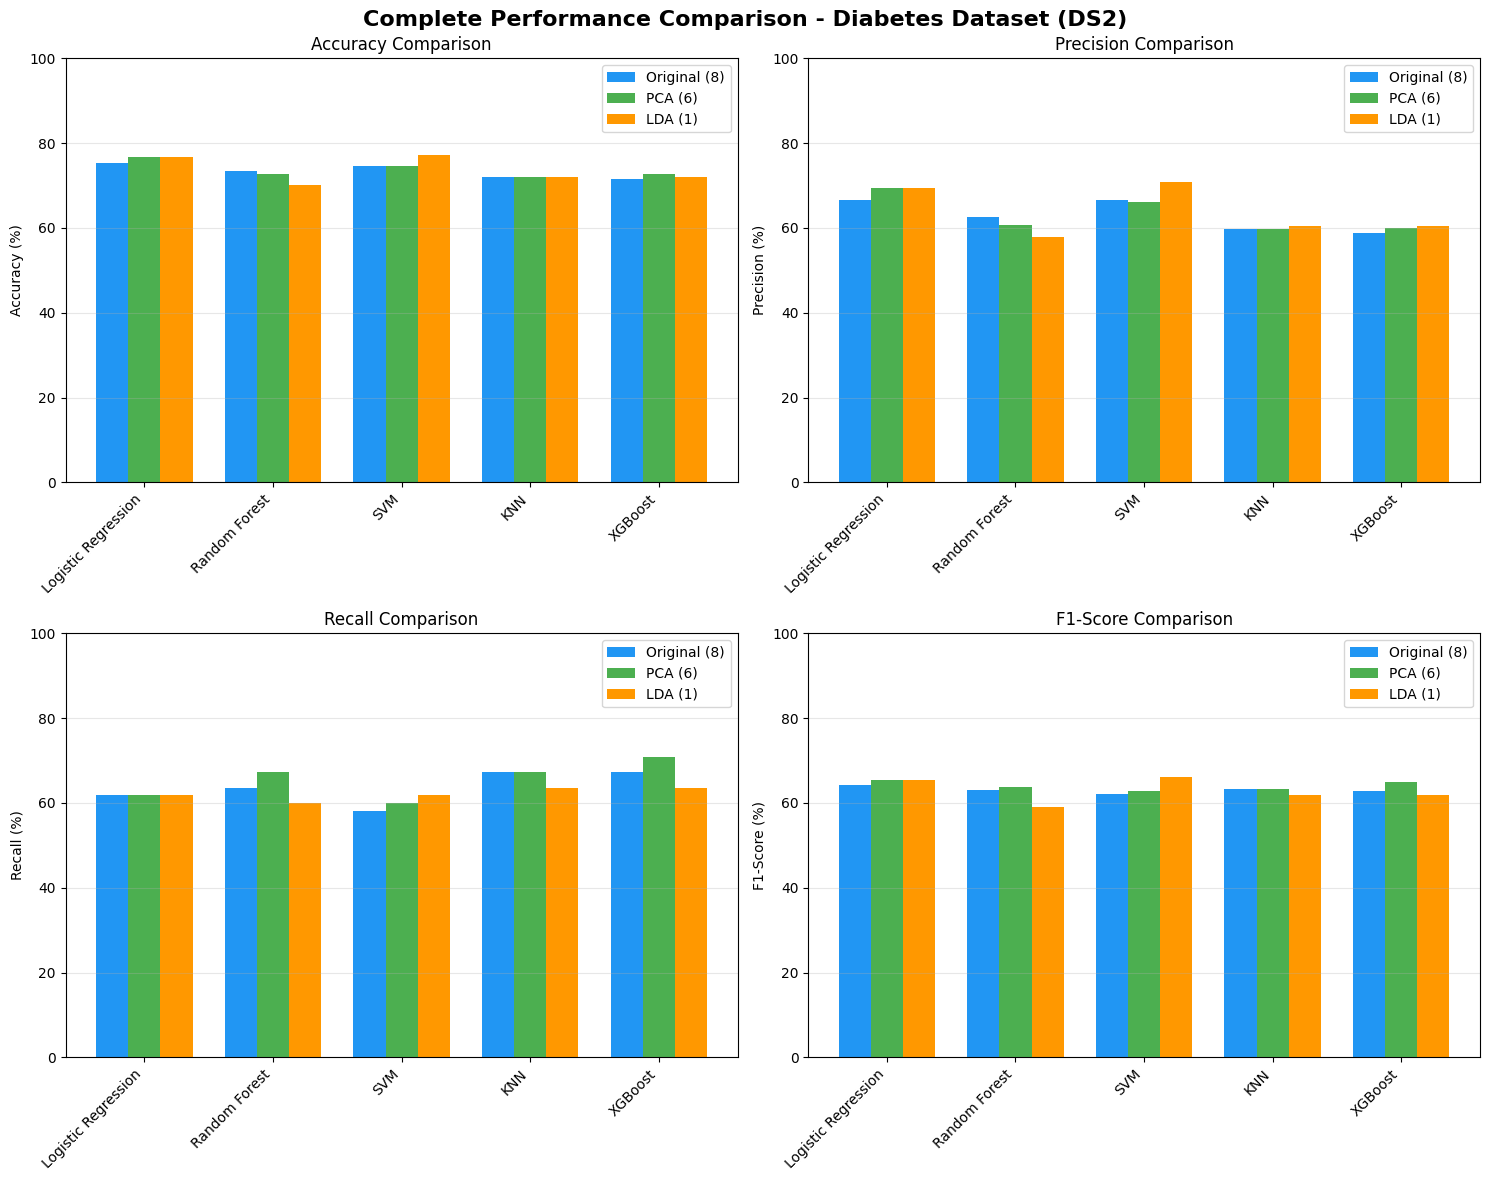

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_data = [metrics_original, metrics_pca, metrics_lda]
dataset_names = ['Original (8)', 'PCA (6)', 'LDA (1)']

for idx, metric in enumerate(metric_names):
    ax = axes[idx//2, idx%2]

    data = []
    for ds_name, metric_data in zip(dataset_names, metrics_data):
        values = [metric_data[m][metric]*100 for m in models.keys()]
        data.append(values)

    x = np.arange(len(models))
    width = 0.25

    bars1 = ax.bar(x - width, data[0], width, label='Original (8)', color='#2196F3')
    bars2 = ax.bar(x, data[1], width, label='PCA (6)', color='#4CAF50')
    bars3 = ax.bar(x + width, data[2], width, label='LDA (1)', color='#FF9800')

    ax.set_ylabel(f'{metric} (%)')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models.keys(), rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 100)

plt.suptitle('Complete Performance Comparison - Diabetes Dataset (DS2)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()